## 1. Setup

In [1]:
!pip install datasets pillow scikit-learn --quiet

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm
import os
import multiprocessing
import pandas as pd
from collections import Counter
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus = torch.cuda.device_count()
print(f"Device: {device}")
print(f"Available GPUs: {n_gpus}")

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True



workers = os.cpu_count()
print(f"CPU Cores: {workers}")

Device: cuda
Available GPUs: 2
CPU Cores: 4


## Manual Layer Implementations

In [3]:
def conv_forward(x, weight, bias=None, stride=1, padding=0):

    batch, in_ch, H, W = x.shape
    out_ch, _, kH, kW = weight.shape

    if padding > 0:
        x = F.pad(x, (padding, padding, padding, padding))
        H, W = H + 2 * padding, W + 2 * padding

    out_H = (H - kH) // stride + 1
    out_W = (W - kW) // stride + 1

    patches = x.unfold(2, kH, stride).unfold(3, kW, stride)
    patches = patches.contiguous().view(batch, in_ch, out_H, out_W, kH * kW)
    patches = patches.permute(0, 2, 3, 1, 4).contiguous().view(batch, out_H, out_W, in_ch * kH * kW)

    weight_flat = weight.view(out_ch, -1).t()
    output = torch.matmul(patches, weight_flat)
    output = output.permute(0, 3, 1, 2)

    if bias is not None:
        output = output + bias.view(1, -1, 1, 1)
    return output


def max_pool(x, kernel_size, stride=None):

    if stride is None:
        stride = kernel_size
    batch, ch, H, W = x.shape
    out_H = (H - kernel_size) // stride + 1
    out_W = (W - kernel_size) // stride + 1
    patches = x.unfold(2, kernel_size, stride).unfold(3, kernel_size, stride)
    return patches.contiguous().view(batch, ch, out_H, out_W, -1).max(dim=-1)[0]


def adaptive_avg_pool(x, output_size):

    batch, ch, H, W = x.shape
    out_H, out_W = output_size
    if out_H == 1 and out_W == 1:
        return x.mean(dim=(2, 3), keepdim=True)
    stride_H = H // out_H
    stride_W = W // out_W
    kernel_H = H - (out_H - 1) * stride_H
    kernel_W = W - (out_W - 1) * stride_W
    patches = x.unfold(2, kernel_H, stride_H).unfold(3, kernel_W, stride_W)
    return patches.mean(dim=(4, 5))


def batch_norm_forward(x, gamma, beta, running_mean, running_var, training=True, momentum=0.1, eps=1e-5):

    if training:
        mean = x.mean(dim=(0, 2, 3), keepdim=True)
        var = x.var(dim=(0, 2, 3), unbiased=False, keepdim=True)
        with torch.no_grad():
            running_mean.copy_((1 - momentum) * running_mean + momentum * mean.squeeze())
            running_var.copy_((1 - momentum) * running_var + momentum * var.squeeze())
    else:
        mean = running_mean.view(1, -1, 1, 1)
        var = running_var.view(1, -1, 1, 1)
    x_norm = (x - mean) / torch.sqrt(var + eps)
    return gamma.view(1, -1, 1, 1) * x_norm + beta.view(1, -1, 1, 1)


def leaky_relu(x, negative_slope=0.01):

    return torch.where(x > 0, x, x * negative_slope)


def linear_forward(x, weight, bias=None):

    output = torch.matmul(x, weight.t())
    if bias is not None:
        output = output + bias
    return output


def dropout(x, p=0.5, training=True):

    if not training or p == 0:
        return x
    mask = (torch.rand_like(x) > p).float()
    return x * mask / (1 - p)


def spatial_dropout(x, p=0.5, training=True):

    if not training or p == 0:
        return x
    batch, channels, H, W = x.shape
    mask = (torch.rand(batch, channels, 1, 1, device=x.device) > p).float()
    return x * mask / (1 - p)

## Model Architecture

In [4]:
class MusicCNN(nn.Module):
    """

    Channels: 3 -> 28 -> 52 -> 96 -> 144 -> 200

    """

    def __init__(self, num_classes=16, input_size=128):
        super(MusicCNN, self).__init__()
        self.num_classes = num_classes
        self.input_size = input_size

        # Block 1: 3 -> 28
        self.conv1_weight = nn.Parameter(self._kaiming_init(28, 3, 5, 5))
        self.conv1_bias = nn.Parameter(torch.zeros(28))
        self.bn1_gamma = nn.Parameter(torch.ones(28))
        self.bn1_beta = nn.Parameter(torch.zeros(28))
        self.register_buffer('bn1_mean', torch.zeros(28))
        self.register_buffer('bn1_var', torch.ones(28))

        # Block 2: 28 -> 52
        self.conv2_weight = nn.Parameter(self._kaiming_init(52, 28, 3, 3))
        self.conv2_bias = nn.Parameter(torch.zeros(52))
        self.bn2_gamma = nn.Parameter(torch.ones(52))
        self.bn2_beta = nn.Parameter(torch.zeros(52))
        self.register_buffer('bn2_mean', torch.zeros(52))
        self.register_buffer('bn2_var', torch.ones(52))

        # Block 3: 52 -> 96
        self.conv3_weight = nn.Parameter(self._kaiming_init(96, 52, 3, 3))
        self.conv3_bias = nn.Parameter(torch.zeros(96))
        self.bn3_gamma = nn.Parameter(torch.ones(96))
        self.bn3_beta = nn.Parameter(torch.zeros(96))
        self.register_buffer('bn3_mean', torch.zeros(96))
        self.register_buffer('bn3_var', torch.ones(96))

        # Block 4: 96 -> 144
        self.conv4_weight = nn.Parameter(self._kaiming_init(144, 96, 3, 3))
        self.conv4_bias = nn.Parameter(torch.zeros(144))
        self.bn4_gamma = nn.Parameter(torch.ones(144))
        self.bn4_beta = nn.Parameter(torch.zeros(144))
        self.register_buffer('bn4_mean', torch.zeros(144))
        self.register_buffer('bn4_var', torch.ones(144))

        # Block 5: 144 -> 200
        self.conv5_weight = nn.Parameter(self._kaiming_init(200, 144, 3, 3))
        self.conv5_bias = nn.Parameter(torch.zeros(200))
        self.bn5_gamma = nn.Parameter(torch.ones(200))
        self.bn5_beta = nn.Parameter(torch.zeros(200))
        self.register_buffer('bn5_mean', torch.zeros(200))
        self.register_buffer('bn5_var', torch.ones(200))

        # FC: 200 -> 128 -> num_classes
        self.fc1_weight = nn.Parameter(self._kaiming_init(128, 200))
        self.fc1_bias = nn.Parameter(torch.zeros(128))
        self.fc2_weight = nn.Parameter(self._kaiming_init(num_classes, 128))
        self.fc2_bias = nn.Parameter(torch.zeros(num_classes))

        # Dropout rates
        self.spatial_drop = [0.04, 0.05, 0.06, 0.07, 0.08, 0.09]
        self.final_drop = 0.50

    def _kaiming_init(self, out_ch, in_ch, *kernel_size):
        k_prod = 1
        for k in kernel_size:
            k_prod *= k
        fan_in = in_ch * k_prod
        std = math.sqrt(2.0 / fan_in)
        shape = (out_ch, in_ch) + kernel_size
        return torch.randn(shape) * std

    def _xavier_init(self, out_f, in_f):
        std = math.sqrt(2.0 / (in_f + out_f))
        return torch.randn(out_f, in_f) * std

    def forward(self, x):
        # Block 1
        x = conv_forward(x, self.conv1_weight, self.conv1_bias, stride=1, padding=2)
        x = batch_norm_forward(x, self.bn1_gamma, self.bn1_beta, self.bn1_mean, self.bn1_var, self.training)
        x = leaky_relu(x)
        x = max_pool(x, 2)
        x = spatial_dropout(x, self.spatial_drop[0], self.training)

        # Block 2
        x = conv_forward(x, self.conv2_weight, self.conv2_bias, stride=1, padding=1)
        x = batch_norm_forward(x, self.bn2_gamma, self.bn2_beta, self.bn2_mean, self.bn2_var, self.training)
        x = leaky_relu(x)
        x = max_pool(x, 2)
        x = spatial_dropout(x, self.spatial_drop[1], self.training)

        # Block 3
        x = conv_forward(x, self.conv3_weight, self.conv3_bias, stride=1, padding=1)
        x = batch_norm_forward(x, self.bn3_gamma, self.bn3_beta, self.bn3_mean, self.bn3_var, self.training)
        x = leaky_relu(x)
        x = max_pool(x, 2)
        x = spatial_dropout(x, self.spatial_drop[2], self.training)

        # Block 4
        x = conv_forward(x, self.conv4_weight, self.conv4_bias, stride=1, padding=1)
        x = batch_norm_forward(x, self.bn4_gamma, self.bn4_beta, self.bn4_mean, self.bn4_var, self.training)
        x = leaky_relu(x)
        x = max_pool(x, 2)
        x = spatial_dropout(x, self.spatial_drop[3], self.training)

        # Block 5
        x = conv_forward(x, self.conv5_weight, self.conv5_bias, stride=1, padding=1)
        x = batch_norm_forward(x, self.bn5_gamma, self.bn5_beta, self.bn5_mean, self.bn5_var, self.training)
        x = leaky_relu(x)
        x = spatial_dropout(x, self.spatial_drop[4], self.training)

        # GAP + FC
        x = adaptive_avg_pool(x, (1, 1))
        x = x.view(x.shape[0], -1)

        x = linear_forward(x, self.fc1_weight, self.fc1_bias)
        x = leaky_relu(x)
        x = dropout(x, self.final_drop, self.training)
        x = linear_forward(x, self.fc2_weight, self.fc2_bias)

        return x



## Data Augmentation

In [5]:
class SpecAugment(object):
    """SpecAugment: time and frequency masking."""

    def __init__(self, time_mask=18, freq_mask=14, p=0.5, num_masks=2):
        self.time_mask = time_mask
        self.freq_mask = freq_mask
        self.p = p
        self.num_masks = num_masks

    def __call__(self, x):
        if torch.rand(1) > self.p:
            return x

        _, h, w = x.shape
        for _ in range(self.num_masks):
            f_width = torch.randint(1, self.freq_mask + 1, (1,)).item()
            if h > f_width:
                y0 = torch.randint(0, h - f_width, (1,)).item()
                x[:, y0:y0 + f_width, :] = x.mean()

            t_width = torch.randint(1, self.time_mask + 1, (1,)).item()
            if w > t_width:
                x0 = torch.randint(0, w - t_width, (1,)).item()
                x[:, :, x0:x0 + t_width] = x.mean()
        return x


class RandomTimeShift(object):
    """Circular shift along time axis."""

    def __init__(self, max_shift=50, p=0.3):
        self.max_shift = max_shift
        self.p = p

    def __call__(self, x):
        if torch.rand(1) > self.p:
            return x

        shift = torch.randint(-self.max_shift, self.max_shift + 1, (1,)).item()
        return torch.roll(x, shifts=shift, dims=2)





class ChromaAugmentation(object):
    """Special augmentation for chromagram (input 3) - only time masking."""

    def __init__(self, time_mask=40, p=0.5):
        self.time_mask = time_mask
        self.p = p

    def __call__(self, x):
        if torch.rand(1) > self.p:
            return x

        _, h, w = x.shape

        # Only time masking for chroma (frequency bins are only 12)
        t_width = torch.randint(1, self.time_mask + 1, (1,)).item()
        if w > t_width:
            x0 = torch.randint(0, w - t_width, (1,)).item()
            x[:, :, x0:x0 + t_width] = x.mean()

        return x


class ComposeWithIndices(object):
    """Apply different augmentations to different inputs."""

    def __init__(self, transforms_list):
        """
        transforms_list: List of (indices, transform) tuples
        indices: list of input indices to apply transform to
        transform: transforms.Compose object
        """
        self.transforms_list = transforms_list

    def __call__(self, images):
        """
        images: list of 3 PIL images [mel, cqt, chroma]
        """
        transformed_images = []

        for idx, img in enumerate(images):
            # Find applicable transforms for this index
            applicable_transforms = []
            for indices, transform in self.transforms_list:
                if idx in indices:
                    applicable_transforms.append(transform)

            # Apply transforms
            transformed_img = img
            for transform in applicable_transforms:
                transformed_img = transform(transformed_img)

            transformed_images.append(transformed_img)

        return transformed_images




In [6]:
class MusicDataset(Dataset):
    """Preprocessing"""
    def __init__(self, csv_file, root_dir, transform=None, norm_layer=None, is_test=False):
        self.metadata = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
        self.norm_layer = norm_layer
        self.is_test = is_test

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        if self.is_test:
            raw_paths = [row['input_1_path'], row['input_2'], row['input_3']]
        else:
            raw_paths = [row['input_1'], row['input_2'], row['input_3']]

        img_paths = [os.path.join(self.root_dir, p.lstrip('./')) for p in raw_paths]
        # Load as RGB (will be converted to grayscale by transforms)
        images = [Image.open(p).convert('RGB') for p in img_paths]

        if self.transform:
            # If transform is ComposeWithIndices, pass all images at once
            if isinstance(self.transform, ComposeWithIndices):
                images = self.transform(images)
            else:
                # Otherwise apply same transform to all
                images = [self.transform(img) for img in images]

        # Concatenate: 3 grayscale images × 1 channel = 3 channels total
        x = torch.cat(images, dim=0)

        if self.norm_layer:
            x = self.norm_layer(x)

        if self.is_test:
            return x

        y = torch.tensor(row['target'], dtype=torch.long)
        return x, y

## Training Functions

In [7]:
def train_one_epoch(model, train_loader, optimizer, scheduler, device, class_weights,
                     label_smoothing=0.12):

    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc='Training')
    for batch_idx, (images, labels) in enumerate(pbar):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = F.cross_entropy(outputs, labels, weight=class_weights, label_smoothing=label_smoothing)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()


        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.5)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        total += labels.size(0)
        pbar.set_postfix({'loss': f'{total_loss/(batch_idx+1):.4f}', 'acc': f'{100.*correct/total:.2f}%'})

    return total_loss / len(train_loader), 100. * correct / total


def validate(model, val_loader, device, class_weights, label_smoothing=0.12):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validating'):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = F.cross_entropy(outputs, labels, weight=class_weights, label_smoothing=label_smoothing)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    accuracy = accuracy_score(all_labels, all_preds) * 100
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return total_loss / len(val_loader), accuracy, f1, all_preds, all_labels

### Data Preparation

In [8]:
BASE_PATH = "/kaggle/input/cs-776-competition-2025-2026-sem-2"
TRAIN_CSV = f"{BASE_PATH}/dataset_music/train/metadata.csv"
IMG_SIZE = 128 # Resize
BATCH_SIZE = 64
NUM_EPOCHS = 90
MAX_LR = 0.0035
WEIGHT_DECAY = 1e-2
LABEL_SMOOTHING = 0.1 # Cross Entropy

# print(f"Epochs: {NUM_EPOCHS}, LR: {MAX_LR}, WD: {WEIGHT_DECAY}, Label Smoothing: {LABEL_SMOOTHING}")


In [9]:
# Preprocessing

mel_cqt_train_aug = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),

    SpecAugment(time_mask=10, freq_mask=14, p=0.5, num_masks=2),
    RandomTimeShift(max_shift=15, p=0.3)
])


chroma_train_aug = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    ChromaAugmentation(time_mask=10, p=0.5),
    RandomTimeShift(max_shift=15, p=0.3)
])

# Apply different transforms to different inputs
train_transform = ComposeWithIndices([
    ([0, 1], mel_cqt_train_aug),  # Input 1 and Input 2
    ([2], chroma_train_aug),       # Input 3
])

# Evaluation transform (no augmentation)
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# Normalization for 3 channels (3 grayscale images)
norm_transform = transforms.Normalize(
    mean=[0.5] * 3,
    std=[0.5] * 3
)




In [10]:
train_data_full = MusicDataset(TRAIN_CSV, BASE_PATH, train_transform, norm_transform)
val_data_full = MusicDataset(TRAIN_CSV, BASE_PATH, eval_transform, norm_transform)

dataset_size = len(train_data_full)
indices = list(range(dataset_size))
train_len = int(0.8 * dataset_size)
torch.manual_seed(44)
train_indices, val_indices = random_split(indices, [train_len, dataset_size - train_len])

train_dataset = Subset(train_data_full, train_indices)
val_dataset = Subset(val_data_full, val_indices)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

Train: 17460, Val: 4365


In [11]:
df = pd.read_csv(TRAIN_CSV)
all_train_labels = df.iloc[list(train_indices)]['target'].values.tolist()
class_counts = Counter(all_train_labels)

counts = torch.tensor([class_counts.get(i, 1) for i in range(16)], dtype=torch.float32)
class_weights = len(all_train_labels) / (16 * counts)
class_weights = class_weights / class_weights.mean()
class_weights = class_weights.to(device) # Used In Weighted Cross Entropy Loss

for i in range(16):
    c = class_counts.get(i, 0)
    print(f'Class {i}: {c} samples ({c/len(all_train_labels)*100:.1f}%)')


print('Class weights:')
for i, w in enumerate(class_weights):
    print(f'  Class {i}: {w:.3f}')

Class 0: 1803 samples (10.3%)
Class 1: 668 samples (3.8%)
Class 2: 1340 samples (7.7%)
Class 3: 1765 samples (10.1%)
Class 4: 768 samples (4.4%)
Class 5: 985 samples (5.6%)
Class 6: 959 samples (5.5%)
Class 7: 860 samples (4.9%)
Class 8: 1259 samples (7.2%)
Class 9: 853 samples (4.9%)
Class 10: 956 samples (5.5%)
Class 11: 1905 samples (10.9%)
Class 12: 979 samples (5.6%)
Class 13: 614 samples (3.5%)
Class 14: 878 samples (5.0%)
Class 15: 868 samples (5.0%)
Class weights:
  Class 0: 0.542
  Class 1: 1.464
  Class 2: 0.730
  Class 3: 0.554
  Class 4: 1.273
  Class 5: 0.993
  Class 6: 1.019
  Class 7: 1.137
  Class 8: 0.777
  Class 9: 1.146
  Class 10: 1.023
  Class 11: 0.513
  Class 12: 0.999
  Class 13: 1.592
  Class 14: 1.113
  Class 15: 1.126


In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=workers, pin_memory=True)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 273, Val batches: 35


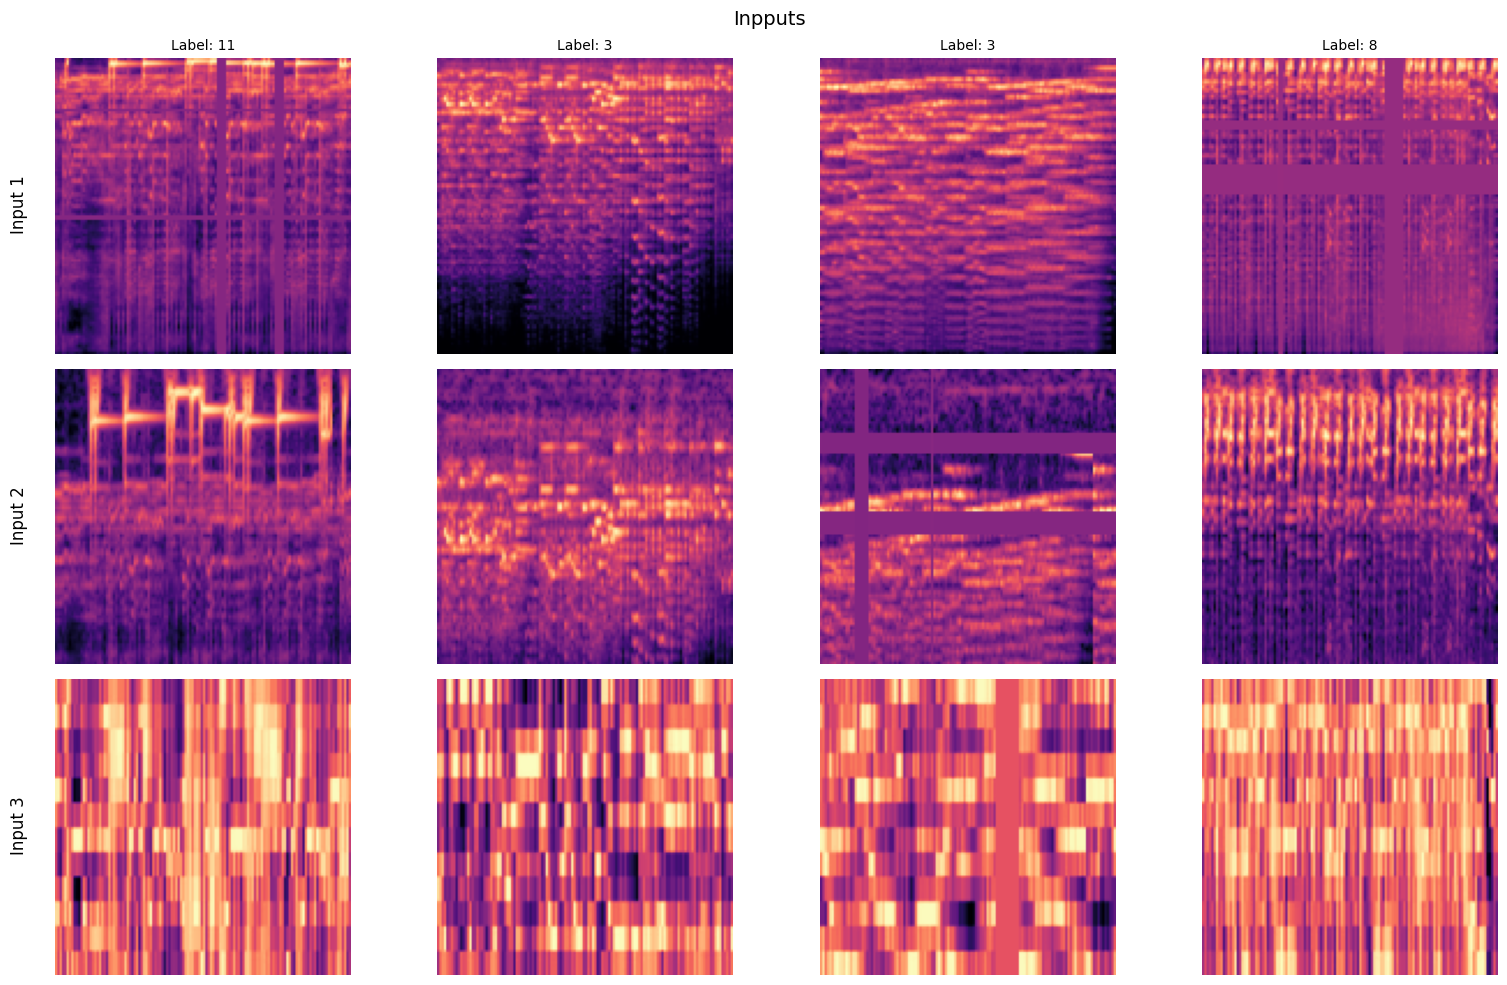

In [13]:


fig, axes = plt.subplots(3, 4, figsize=(16, 10))


input_names = ['Input 1', 'Input 2', 'Input 3']

for col in range(4):

    img_tensor, label = train_dataset[col * 100]

    # Row 0: Input 1 (Channel 0)
    # Slice first channel, shape becomes (128, 128)
    img1 = img_tensor[0, :, :].numpy()
    # Denormalize & Clip
    img1 = (img1 * 0.5) + 0.5
    img1 = img1.clip(0, 1)

    axes[0, col].imshow(img1, cmap='magma', origin='lower')
    axes[0, col].set_title(f'Label: {label.item()}', fontsize=10)
    axes[0, col].axis('off')

    # Row 1: Input 2 (Channel 1)
    img2 = img_tensor[1, :, :].numpy()
    img2 = (img2 * 0.5) + 0.5
    img2 = img2.clip(0, 1)

    axes[1, col].imshow(img2, cmap='magma', origin='lower')
    axes[1, col].axis('off')

    # Row 2: Input 3 (Channel 2)
    img3 = img_tensor[2, :, :].numpy()
    img3 = (img3 * 0.5) + 0.5
    img3 = img3.clip(0, 1)

    axes[2, col].imshow(img3, cmap='magma', origin='lower')
    axes[2, col].axis('off')


for i in range(3):
    axes[i, 0].set_ylabel(input_names[i], fontsize=12, rotation=90)

    axes[i, 0].text(-20, 64, input_names[i], fontsize=12, rotation=90, va='center')

plt.suptitle('Inpputs', fontsize=14)
plt.tight_layout()
plt.show()


## Model Initialization

In [14]:
model = MusicCNN(num_classes=16, input_size=IMG_SIZE).to(device)

# Multi-GPU
if n_gpus > 1:
    print(f"Using {n_gpus} GPUs")
    model = nn.DataParallel(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")


Using 2 GPUs
Total trainable parameters: 473,100


In [15]:
optimizer = torch.optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=WEIGHT_DECAY)
steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * NUM_EPOCHS
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=MAX_LR, epochs=NUM_EPOCHS, total_steps=total_steps,
    pct_start=0.10, div_factor=25, final_div_factor=1000
)



## Training

In [16]:
checkpoint_path = f"best_model.pth"
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0



In [17]:
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, device, class_weights,
        label_smoothing=LABEL_SMOOTHING
    )

    val_loss, val_acc, val_f1, val_preds, val_labels = validate(
        model, val_loader, device, class_weights, LABEL_SMOOTHING
    )


    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.2f}% | F1: {val_f1:.4f} | LR: {current_lr:.6f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'val_f1': val_f1}, checkpoint_path)
        print(f"New best F1: {val_f1:.4f}")



print(f"\nTraining complete. Best F1: {best_val_f1:.4f}")


Epoch 1/90


Validating: 100%|██████████| 35/35 [00:26<00:00,  1.31it/s]


Train Loss: 2.6647 | Acc: 16.27%
Val Loss: 2.2956 | Acc: 29.16% | F1: 0.2467 | LR: 0.000241
New best F1: 0.2467

Epoch 2/90


Validating: 100%|██████████| 35/35 [00:15<00:00,  2.27it/s]


Train Loss: 2.3862 | Acc: 25.46%
Val Loss: 2.0970 | Acc: 40.48% | F1: 0.3585 | LR: 0.000533
New best F1: 0.3585

Epoch 3/90


...

Train Loss: 0.8035 | Acc: 96.67%
Val Loss: 0.8352 | Acc: 94.04% | F1: 0.9369 | LR: 0.000005

Epoch 89/90


Validating: 100%|██████████| 35/35 [00:16<00:00,  2.16it/s]


Train Loss: 0.8027 | Acc: 96.70%
Val Loss: 0.8366 | Acc: 94.16% | F1: 0.9378 | LR: 0.000001
New best F1: 0.9378

Epoch 90/90


Validating: 100%|██████████| 35/35 [00:15<00:00,  2.23it/s]

Train Loss: 0.8030 | Acc: 96.55%
Val Loss: 0.8358 | Acc: 93.95% | F1: 0.9361 | LR: 0.000000

Training complete. Best F1: 0.9378


## Evaluation

In [18]:
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

val_loss, val_acc, val_f1, val_preds, val_labels = validate(model, val_loader, device, class_weights, LABEL_SMOOTHING)

precision = precision_score(val_labels, val_preds, average='macro', zero_division=0)
recall = recall_score(val_labels, val_preds, average='macro', zero_division=0)
conf_matrix = confusion_matrix(val_labels, val_preds)

print("\n" + "="*50)
print("VALIDATION METRICS")
print("="*50)
print(f"Accuracy:  {val_acc:.4f}%")
print(f"Precision: {precision:.6f}")
print(f"Recall:    {recall:.6f}")
print(f"F1 Score:  {val_f1:.6f}")
print("="*50)

Validating: 100%|██████████| 35/35 [00:15<00:00,  2.30it/s]


VALIDATION METRICS
Accuracy:  94.1581%
Precision: 0.936903
Recall:    0.939348
F1 Score:  0.937820


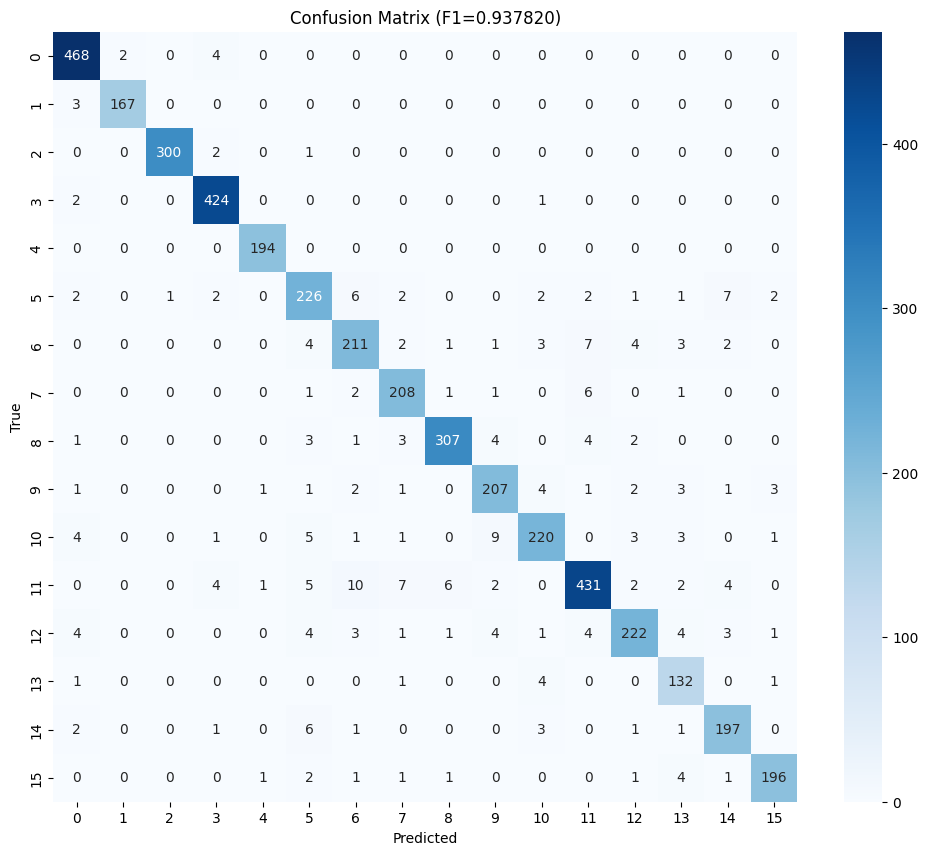

In [19]:
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (F1={val_f1:.6f})')
plt.show()

## Training Curves

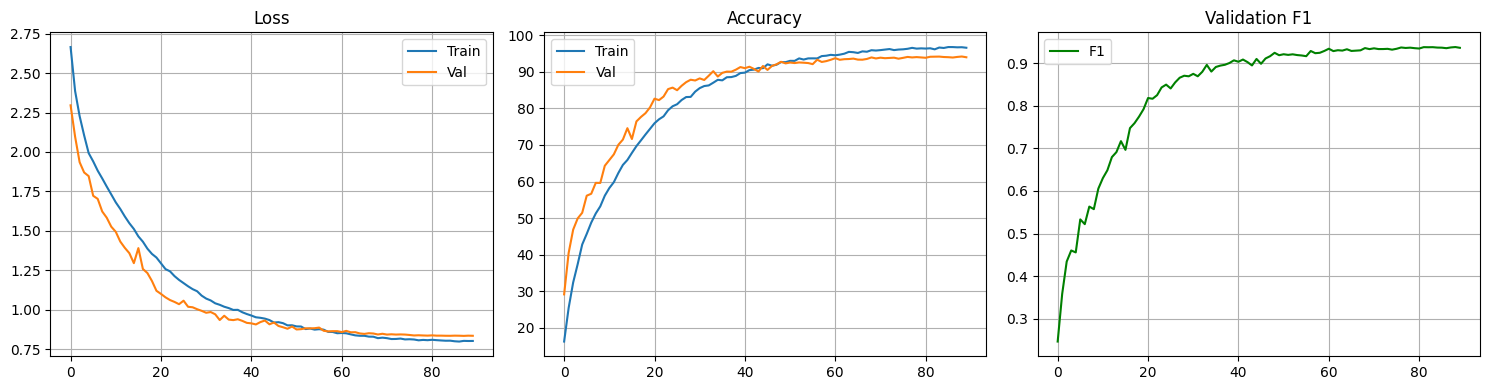

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history['val_f1'], label='F1', color='green')
axes[2].set_title('Validation F1')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [21]:

# PER-CLASS METRICS

print("\n" + "="*80)
print("PER-CLASS METRICS")
print("="*80)


per_class_precision = precision_score(val_labels, val_preds, average=None, zero_division=0)
per_class_recall = recall_score(val_labels, val_preds, average=None, zero_division=0)
per_class_f1 = f1_score(val_labels, val_preds, average=None, zero_division=0)

print(f"\n{'Class':<35} {'Precision':>12} {'Recall':>12} {'F1-Score':>12}")
print("-"*75)

for i in range(16):
    print(f"{i:<35} {per_class_precision[i]*100:>11.4f}% {per_class_recall[i]*100:>11.4f}% {per_class_f1[i]*100:>11.4f}%")

print("-"*75)
print(f"{'MACRO AVERAGE':<35} {precision*100:>11.4f}% {recall*100:>11.4f}% {val_f1*100:>11.4f}%")
print("="*80)


PER-CLASS METRICS

Class                                  Precision       Recall     F1-Score
---------------------------------------------------------------------------
0                                       95.9016%     98.7342%     97.2973%
1                                       98.8166%     98.2353%     98.5251%
2                                       99.6678%     99.0099%     99.3377%
3                                       96.8037%     99.2974%     98.0347%
4                                       98.4772%    100.0000%     99.2327%
5                                       87.5969%     88.9764%     88.2812%
6                                       88.6555%     88.6555%     88.6555%
7                                       91.6300%     94.5455%     93.0649%
8                                       96.8454%     94.4615%     95.6386%
9                                       90.7895%     91.1894%     90.9890%
10                                      92.4370%     88.7097%     90.5350%
11  

In [22]:

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("MODEL PARAMETER COUNT")
print("=" * 60)
print(f"Total trainable parameters: {total_params:,}")

# Detailed breakdown
print("\nParameter breakdown:")

# Block 1: 3->28, 5x5 kernel
# Weight: 28*3*5*5, Bias: 28
c1 = 28*3*5*5 + 28
bn1 = 28 + 28
print(f"  Conv1 (3->28, 5x5):    {c1:>8,} params")
print(f"  BN1 (28 channels):     {bn1:>8,} params")

# Block 2: 28->52, 3x3 kernel
# Weight: 52*28*3*3, Bias: 52
c2 = 52*28*3*3 + 52
bn2 = 52 + 52
print(f"  Conv2 (28->52, 3x3):   {c2:>8,} params")
print(f"  BN2 (52 channels):     {bn2:>8,} params")

# Block 3: 52->96, 3x3 kernel
# Weight: 96*52*3*3, Bias: 96
c3 = 96*52*3*3 + 96
bn3 = 96 + 96
print(f"  Conv3 (52->96, 3x3):   {c3:>8,} params")
print(f"  BN3 (96 channels):     {bn3:>8,} params")

# Block 4: 96->144, 3x3 kernel
# Weight: 144*96*3*3, Bias: 144
c4 = 144*96*3*3 + 144
bn4 = 144 + 144
print(f"  Conv4 (96->144, 3x3):  {c4:>8,} params")
print(f"  BN4 (144 channels):    {bn4:>8,} params")

# Block 5: 144->200, 3x3 kernel
# Weight: 200*144*3*3, Bias: 200
c5 = 200*144*3*3 + 200
bn5 = 200 + 200
print(f"  Conv5 (144->200, 3x3): {c5:>8,} params")
print(f"  BN5 (200 channels):    {bn5:>8,} params")

# FC Layers: 200->128->16
fc1 = 128*200 + 128
fc2 = 16*128 + 16
print(f"  FC1 (200->128):        {fc1:>8,} params")
print(f"  FC2 (128->16):         {fc2:>8,} params")

print(f"  {'='*35}")

# Calculate expected total
expected = c1 + bn1 + c2 + bn2 + c3 + bn3 + c4 + bn4 + c5 + bn5 + fc1 + fc2

print(f"  Expected Total:        {expected:>8,} params")
print(f"  Actual Total:          {total_params:>8,} params")

print("=" * 60)

MODEL PARAMETER COUNT
Total trainable parameters: 473,100

Parameter breakdown:
  Conv1 (3->28, 5x5):       2,128 params
  BN1 (28 channels):           56 params
  Conv2 (28->52, 3x3):     13,156 params
  BN2 (52 channels):          104 params
  Conv3 (52->96, 3x3):     45,024 params
  BN3 (96 channels):          192 params
  Conv4 (96->144, 3x3):   124,560 params
  BN4 (144 channels):         288 params
  Conv5 (144->200, 3x3):  259,400 params
  BN5 (200 channels):         400 params
  FC1 (200->128):          25,728 params
  FC2 (128->16):            2,064 params
  Expected Total:         473,100 params
  Actual Total:           473,100 params


## Test Inference

In [23]:
TEST_CSV = f"{BASE_PATH}/dataset_music/test/metadata.csv"

test_dataset = MusicDataset(TEST_CSV, BASE_PATH, eval_transform, norm_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f"Test samples: {len(test_dataset)}")

Test samples: 14550


In [24]:
model.eval()
test_preds = []

with torch.no_grad():
    for images in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_preds.extend(predicted.cpu().numpy())

submission_df = pd.DataFrame({'id': range(len(test_preds)), 'target': test_preds})
submission_df.to_csv('submission.csv', index=False)
print("Saved submission.csv")
print(submission_df.head())

Testing: 100%|██████████| 114/114 [03:04<00:00,  1.62s/it]

Saved submission.csv
   id  target
0   0       3
1   1       8
2   2       8
3   3       0
4   4      11
